In [5]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets.utils import download_and_extract_archive

In [ ]:
root = "data/coco"
train_dir = os.path.join(root, "train2017")
test_dir = os.path.join(root, "test2017")
val_dir = os.path.join(root, "val2017")
unlabeled_dir = os.path.join(root, "unlabeled2017")

os.makedirs(root, exist_ok=True)

if not os.path.exists(train_dir):
    print("Downloading COCO train2017 images...")
    download_and_extract_archive(
        url="http://images.cocodataset.org/zips/train2017.zip",
        download_root=root,
    )

if not os.path.exists(test_dir):
    print("Downloading COCO test2017 images...")
    download_and_extract_archive(
        url="http://images.cocodataset.org/zips/test2017.zip",
        download_root=root,
    )

if not os.path.exists(val_dir):
    print("Downloading COCO val2017 images...")
    download_and_extract_archive(
        url="http://images.cocodataset.org/zips/val2017.zip",
        download_root=root,
    )

if not os.path.exists(unlabeled_dir):
    print("Downloading COCO unlabeled2017 images...")
    download_and_extract_archive(
        url="http://images.cocodataset.org/zips/unlabeled2017.zip",
        download_root=root,
    )

In [ ]:
from torch.utils.data import ConcatDataset

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(128),        # krótszy bok = 128
    transforms.CenterCrop(128),    # 128x128
    transforms.ToTensor(),         # float32 [0,1]
])

# Dataset bez adnotacji
class CocoImagesOnly(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = sorted([
            f for f in os.listdir(img_dir)
            if f.endswith(".jpg")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

train_dataset = CocoImagesOnly(train_dir, transform=transform)
test_dataset = CocoImagesOnly(test_dir, transform=transform)
val_dataset = CocoImagesOnly(val_dir, transform=transform)
unlabeled_dataset = CocoImagesOnly(unlabeled_dir, transform=transform)

all_dataset = ConcatDataset([train_dataset, test_dataset, val_dataset, unlabeled_dataset])

loader = DataLoader(
    all_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("COCO images train:", len(train_dataset))
print("COCO images test:", len(test_dataset))
print("COCO images val:", len(val_dataset))
print("COCO images unlabeled:", len(unlabeled_dataset))
print("COCO images total:", len(all_dataset))

images = next(iter(loader))
print(images.shape)

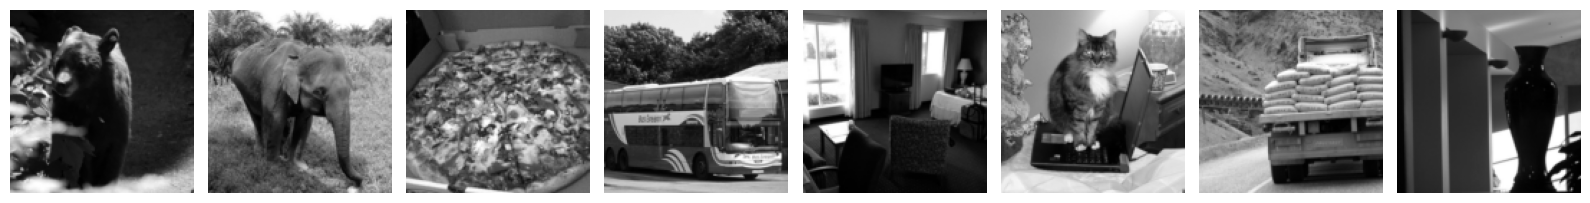

In [25]:
from matplotlib import pyplot as plt

images = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    axes[i].imshow(images[i, 0], cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (128, 128)
PIXEL_SPACING = [1.0, 1.0]
HU_MIN, HU_MAX = -1000, 3000
OUTPUT_DIR = "../data/dicom_coco"

In [ ]:
from pydicom.dataset import Dataset, FileDataset, FileMetaDataset
import numpy as np
import pydicom
from datetime import datetime

os.makedirs(OUTPUT_DIR, exist_ok=True)

for i in range(len(all_dataset)):
    img_tensor = all_dataset[i]  # [1, H, W]
    img_np = img_tensor[0].numpy()

    # --- mapowanie [0,1] -> HU range ---
    img_hu = img_np * (HU_MAX - HU_MIN) + HU_MIN
    img_hu = img_hu.astype(np.int16)

    # --- DICOM FILE META ---
    file_meta = FileMetaDataset()
    file_meta.MediaStorageSOPClassUID = pydicom.uid.CTImageStorage
    file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid()
    file_meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian

    ds = FileDataset(
        filename_or_obj=None,
        dataset=Dataset(),
        file_meta=file_meta,
        preamble=b"\0" * 128,
    )

    # --- Identifiers ---
    ds.SOPClassUID = file_meta.MediaStorageSOPClassUID
    ds.SOPInstanceUID = file_meta.MediaStorageSOPInstanceUID
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()

    ds.Modality = "CT"
    ds.ImageType = ["ORIGINAL", "PRIMARY", "AXIAL"]
    ds.PatientName = "PATIENT^PHANTOM"
    ds.PatientID = f"PATIENT_{i:06d}"

    ds.StudyDate = datetime.now().strftime("%Y%m%d")
    ds.StudyTime = datetime.now().strftime("%H%M%S")

    # --- Geometry ---
    ds.Rows, ds.Columns = IMG_SIZE
    ds.PixelSpacing = PIXEL_SPACING
    ds.SliceThickness = 1.0
    ds.ImagePositionPatient = [0.0, 0.0, float(i)]
    ds.ImageOrientationPatient = [1, 0, 0, 0, 1, 0]
    ds.ReconstructionDiameter = max(IMG_SIZE) * PIXEL_SPACING[0]

    # --- Pixel data ---
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 1  # signed int16
    ds.SamplesPerPixel = 1
    ds.PhotometricInterpretation = "MONOCHROME2"

    ds.RescaleIntercept = 0
    ds.RescaleSlope = 1

    ds.PixelData = img_hu.tobytes()

    filename = os.path.join(OUTPUT_DIR, f"CT_COCO_{i:06d}.dcm")
    ds.save_as(filename)

print("DICOM dataset generated for all samples:", OUTPUT_DIR, "| Total:", len(all_dataset))